In [23]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt
gc.collect()
torch.cuda.empty_cache()

device = torch.device('cuda')
print("GPUs available:", torch.cuda.device_count())

GPUs available: 2


In [24]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class PreCroppedPatchDataset(Dataset):
    def __init__(self, split_dir, mask_base_dir):
        self.img_dir = split_dir
        self.fs_dir = os.path.join(mask_base_dir, 'fastsam')
        self.gt_dir = os.path.join(mask_base_dir, 'gt')
        self.img_files = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        mask_name = img_name.replace('.jpg', '.png')
        
        img = cv2.imread(os.path.join(self.img_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fs_mask = cv2.imread(os.path.join(self.fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.imread(os.path.join(self.gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)
        
        img_tensor = torch.from_numpy(img.astype(np.float32) / 255.0).permute(2, 0, 1)
        fs_tensor = torch.from_numpy((fs_mask > 127).astype(np.float32)).unsqueeze(0)
        gt_tensor = torch.from_numpy((gt_mask > 127).astype(np.float32)).unsqueeze(0)
        
        return img_tensor, fs_tensor, gt_tensor

In [25]:
# ==========================================
# 1. MODEL & LOSS CLASSES
# ==========================================

class ResBlock(nn.Module):
    def __init__(self, channels, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv2(self.relu(self.conv1(x)))

# MODEL 1: The Puller (Deep & Narrow, snaps to edges)
class BoundaryPuller(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.mask_stem = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.pre_loop = nn.Sequential(
            nn.Conv2d(24, 24, kernel_size=3, padding=1), nn.ReLU(inplace=True)
        )
        self.looper = nn.Sequential(
            ResBlock(24, dilation=1),
            ResBlock(24, dilation=2),
            ResBlock(24, dilation=4),
            nn.Conv2d(24, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, init_mask, iters=3):
        img_feats = self.img_stem(img)
        curr_logits = (init_mask - 0.5) * 2.0 

        for _ in range(iters):
            curr_mask = torch.sigmoid(curr_logits)
            mask_feats = self.mask_stem(curr_mask)
            x = torch.cat([img_feats, mask_feats], dim=1)
            x = self.pre_loop(x)
            delta = self.looper(x)
            curr_logits = curr_logits + delta
            
        return torch.sigmoid(curr_logits)


# MODEL 2: The Smoother (Shallow, just irons out the jaggies)
class BoundarySmoother(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1)
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        logits = self.net(x)
        return torch.sigmoid(logits)


# LOSS 1: Just the soft boundary BCE to pull the edge perfectly
class PullerLoss(nn.Module):
    def __init__(self, blur_kernel=11):
        super().__init__()
        self.blur_kernel = blur_kernel

    def forward(self, pred, target):
        dilated = F.max_pool2d(target, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-target, kernel_size=3, stride=1, padding=1)
        gt_boundary = dilated - eroded
        
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        weight_map = 0.2 + (4.8 * (soft_glow / (soft_glow.max() + 1e-6)))
        
        bce = F.binary_cross_entropy(pred, target, reduction='none')
        return (bce * weight_map).mean()


# LOSS 2: Local Density & Smooth Boundary Loss
class SmoothBoundaryLoss(nn.Module):
    def __init__(self, blur_kernel=31, scatter_weight=2.0):
        super().__init__()
        self.blur_kernel = blur_kernel
        self.scatter_weight = scatter_weight 

    def extract_boundary(self, mask):
        dilated = F.max_pool2d(mask, kernel_size=3, stride=1, padding=1)
        eroded = -F.max_pool2d(-mask, kernel_size=3, stride=1, padding=1)
        return dilated - eroded

    def forward(self, pred, target):
        # 1. Base BCE with soft boundary weights
        gt_boundary = self.extract_boundary(target)
        soft_glow = F.avg_pool2d(gt_boundary, kernel_size=self.blur_kernel, stride=1, padding=self.blur_kernel//2)
        glow_norm = soft_glow / (soft_glow.max() + 1e-6)
        
        weight_map = 0.2 + (4.8 * glow_norm)
        
        bce_loss = F.binary_cross_entropy(pred, target, reduction='none')
        weighted_bce = (bce_loss * weight_map).mean()
        
        # 2. Scattered Pixel / Local Density Loss
        local_density = F.avg_pool2d(pred, kernel_size=7, stride=1, padding=3)
        scatter_penalty = pred * (1.0 - local_density)
        hole_penalty = (1.0 - pred) * local_density
        total_density_penalty = scatter_penalty + hole_penalty
        
        weighted_scatter_loss = (total_density_penalty * weight_map).mean()
        
        return weighted_bce + (self.scatter_weight * weighted_scatter_loss)

In [26]:
# ==========================================
# 2. DATASET LOAD
# ==========================================
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"
train_dataset = PreCroppedPatchDataset(
    os.path.join(base_path, "train"),
    os.path.join(base_path, "train_masks")
)

train_loader = DataLoader(
    train_dataset, batch_size=96, shuffle=True, num_workers=2, pin_memory=True
)

In [27]:
# # ==========================================
# # 3. TRAIN STAGE 1 (THE PULLER)
# # ==========================================
# print("\n--- STARTING STAGE 1: TRAINING BOUNDARY PULLER ---")
# model1 = BoundaryPuller()
# if torch.cuda.device_count() > 1:
#     model1 = nn.DataParallel(model1)
# model1 = model1.to(device)

# criterion1 = PullerLoss(blur_kernel=11)
# optimizer1 = optim.Adam(model1.parameters(), lr=1e-3)

# scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer1, mode='min', factor=0.5, patience=2
# )

# epochs1 = 10
# for epoch in range(epochs1):
#     model1.train()
#     total_loss = 0
    
#     for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
#         imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
#         optimizer1.zero_grad()
#         iters = random.randint(2, 5)
#         m1_preds = model1(imgs, fs_masks, iters)
        
#         loss = criterion1(m1_preds, gt_masks)
#         loss.backward()
#         optimizer1.step()
#         total_loss += loss.item()
        
#         if batch_idx % 20 == 0:
#             print(f"M1 Epoch [{epoch}/{epochs1}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

#     avg_loss = total_loss / len(train_loader)
#     print(f"--- M1 Epoch {epoch} Avg Loss: {avg_loss:.4f} ---")
    
#     scheduler1.step(avg_loss)

# # Save Model 1
# if isinstance(model1, nn.DataParallel):
#     torch.save(model1.module.state_dict(), "/kaggle/working/puller_final.pth")
# else:
#     torch.save(model1.state_dict(), "/kaggle/working/puller_final.pth")

In [28]:
# # ==========================================
# # 4. CLEAR GPU BEFORE STAGE 2
# # ==========================================
# print("\nClearing GPU Memory for Stage 2...")
# model1.eval() # Freeze M1 for Stage 2
# optimizer1 = None
# criterion1 = None
# gc.collect()
# torch.cuda.empty_cache()

In [29]:
# # ==========================================
# # 5. TRAIN STAGE 2 (THE SMOOTHER)
# # ==========================================
# print("\n--- STARTING STAGE 2: TRAINING BOUNDARY SMOOTHER ---")
# model2 = BoundarySmoother()
# if torch.cuda.device_count() > 1:
#     model2 = nn.DataParallel(model2)
# model2 = model2.to(device)

# criterion2 = SmoothBoundaryLoss(blur_kernel=31, scatter_weight=2.0)
# optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)

# scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer2, mode='min', factor=0.5, patience=2
# )

# epochs2 = 10
# for epoch in range(epochs2):
#     model2.train()
#     total_loss = 0
    
#     for batch_idx, (imgs, fs_masks, gt_masks) in enumerate(train_loader):
#         imgs, fs_masks, gt_masks = imgs.to(device), fs_masks.to(device), gt_masks.to(device)
        
#         # Get M1 predictions without tracking gradients to save memory
#         with torch.no_grad():
#             iters = 4 # Fixed iters for inference
#             m1_preds = model1(imgs, fs_masks, iters)
#             # Threshold it so M2 sees a solid mask, not soft probabilities
#             m1_bin = (m1_preds > 0.5).float()
            
#         optimizer2.zero_grad()
#         m2_preds = model2(imgs, m1_bin)
        
#         loss = criterion2(m2_preds, gt_masks)
#         loss.backward()
#         optimizer2.step()
#         total_loss += loss.item()
        
#         if batch_idx % 20 == 0:
#             print(f"M2 Epoch [{epoch}/{epochs2}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

#     avg_loss = total_loss / len(train_loader)
#     print(f"--- M2 Epoch {epoch} Avg Loss: {avg_loss:.4f} ---")
    
#     scheduler2.step(avg_loss)

# # Save Model 2
# if isinstance(model2, nn.DataParallel):
#     torch.save(model2.module.state_dict(), "/kaggle/working/smoother_final.pth")
# else:
#     torch.save(model2.state_dict(), "/kaggle/working/smoother_final.pth")

# print("\nBoth models trained and saved!")

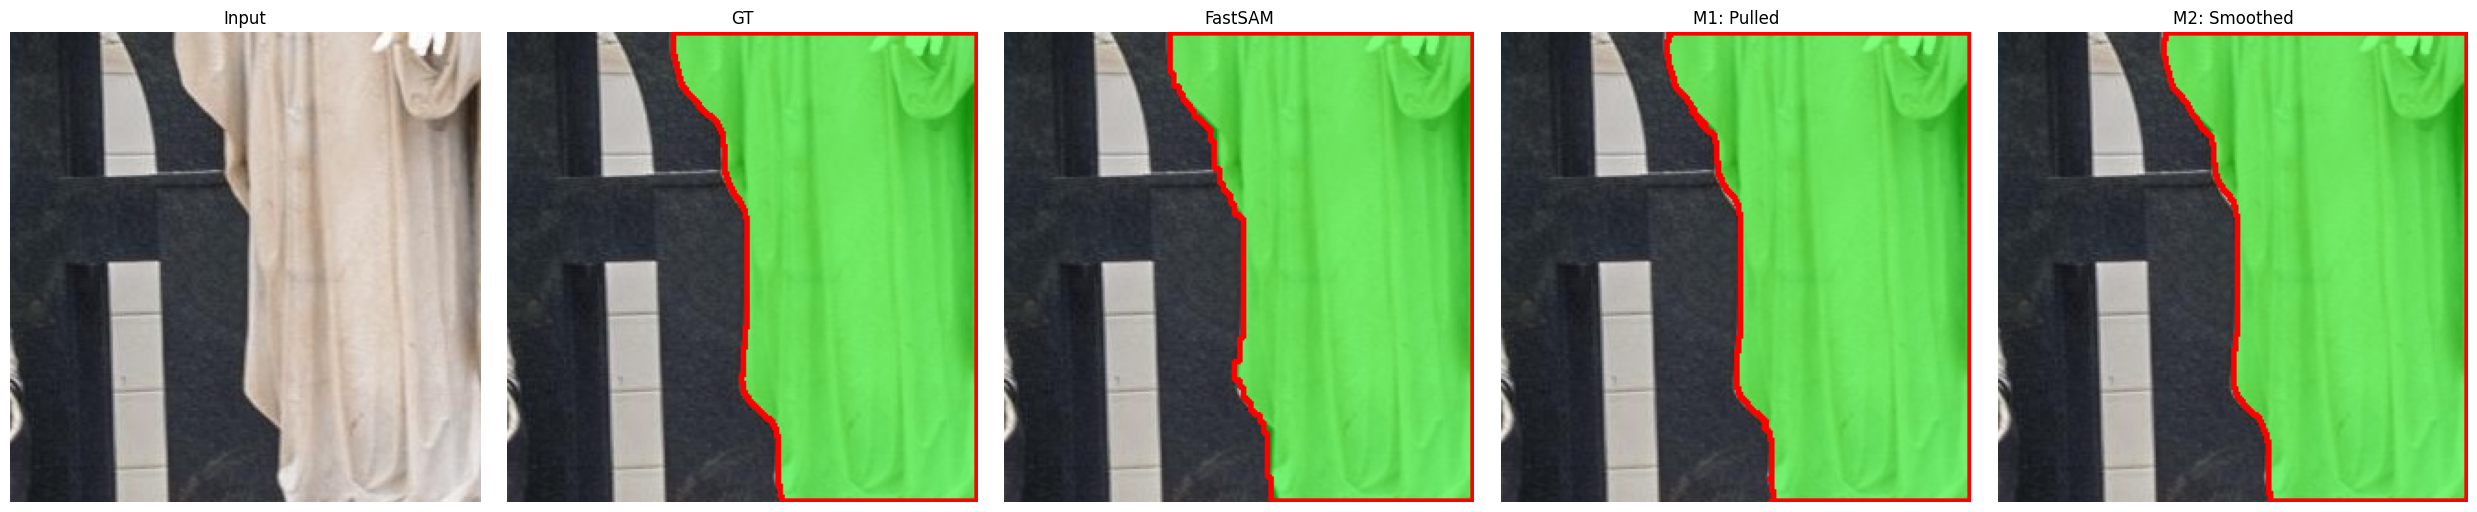

In [30]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

gc.collect()
torch.cuda.empty_cache()

# ===== TEST / VISUALIZATION =====

def create_overlay(img_base, mask, mask_color=(0, 255, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask_bin[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    return overlay


device = torch.device('cuda:0')

# ===== LOAD MODELS =====
# Ensure BoundaryPuller and BoundarySmoother are defined in the cells above
model1 = BoundaryPuller().to(device)
model1.load_state_dict(torch.load("/kaggle/working/puller_final.pth", map_location=device))
model1.eval()

model2 = BoundarySmoother().to(device)
model2.load_state_dict(torch.load("/kaggle/working/smoother_final.pth", map_location=device))
model2.eval()


# ===== PATHS =====
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"

test_img_dir = os.path.join(base_path, "val")
test_fs_dir = os.path.join(base_path, "val_masks/fastsam")
test_gt_dir = os.path.join(base_path, "val_masks/gt")


# ===== RANDOM SAMPLE =====
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
img_name = random.choice(test_imgs)
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(os.path.join(test_gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)
gt_bin = (gt_mask > 127).astype(np.uint8)


# ===== INFERENCE =====
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
            .permute(2, 0, 1).unsqueeze(0).to(device)

fs_t = torch.from_numpy(fs_bin.astype(np.float32))\
           .unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    # Stage 1: Pull the boundary to the actual object edge
    m1_pred_t = model1(img_t, fs_t, iters=10)
    # Threshold it to a hard binary mask for M2
    m1_bin_t = (m1_pred_t > 0.5).float()
    
    # Stage 2: Iron out the jaggies using the TV-trained model
    m2_pred_t = model2(img_t, m1_bin_t)
    
    m1_out = m1_pred_t.squeeze().cpu().numpy()
    m2_out = m2_pred_t.squeeze().cpu().numpy()


# ===== POST-PROCESS =====
m1_bin_np = (m1_out > 0.5).astype(np.uint8)
m2_bin_np = (m2_out > 0.5).astype(np.uint8)


# ===== VISUALIZATION =====
# Expanding to 5 columns so we can see the exact difference Model 2 makes
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(img_rgb); axes[0].set_title("Input")
axes[1].imshow(create_overlay(img_rgb, gt_bin)); axes[1].set_title("GT")
axes[2].imshow(create_overlay(img_rgb, fs_bin)); axes[2].set_title("FastSAM")
axes[3].imshow(create_overlay(img_rgb, m1_bin_np)); axes[3].set_title("M1: Pulled")
axes[4].imshow(create_overlay(img_rgb, m2_bin_np)); axes[4].set_title("M2: Smoothed")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Puller Viz block:

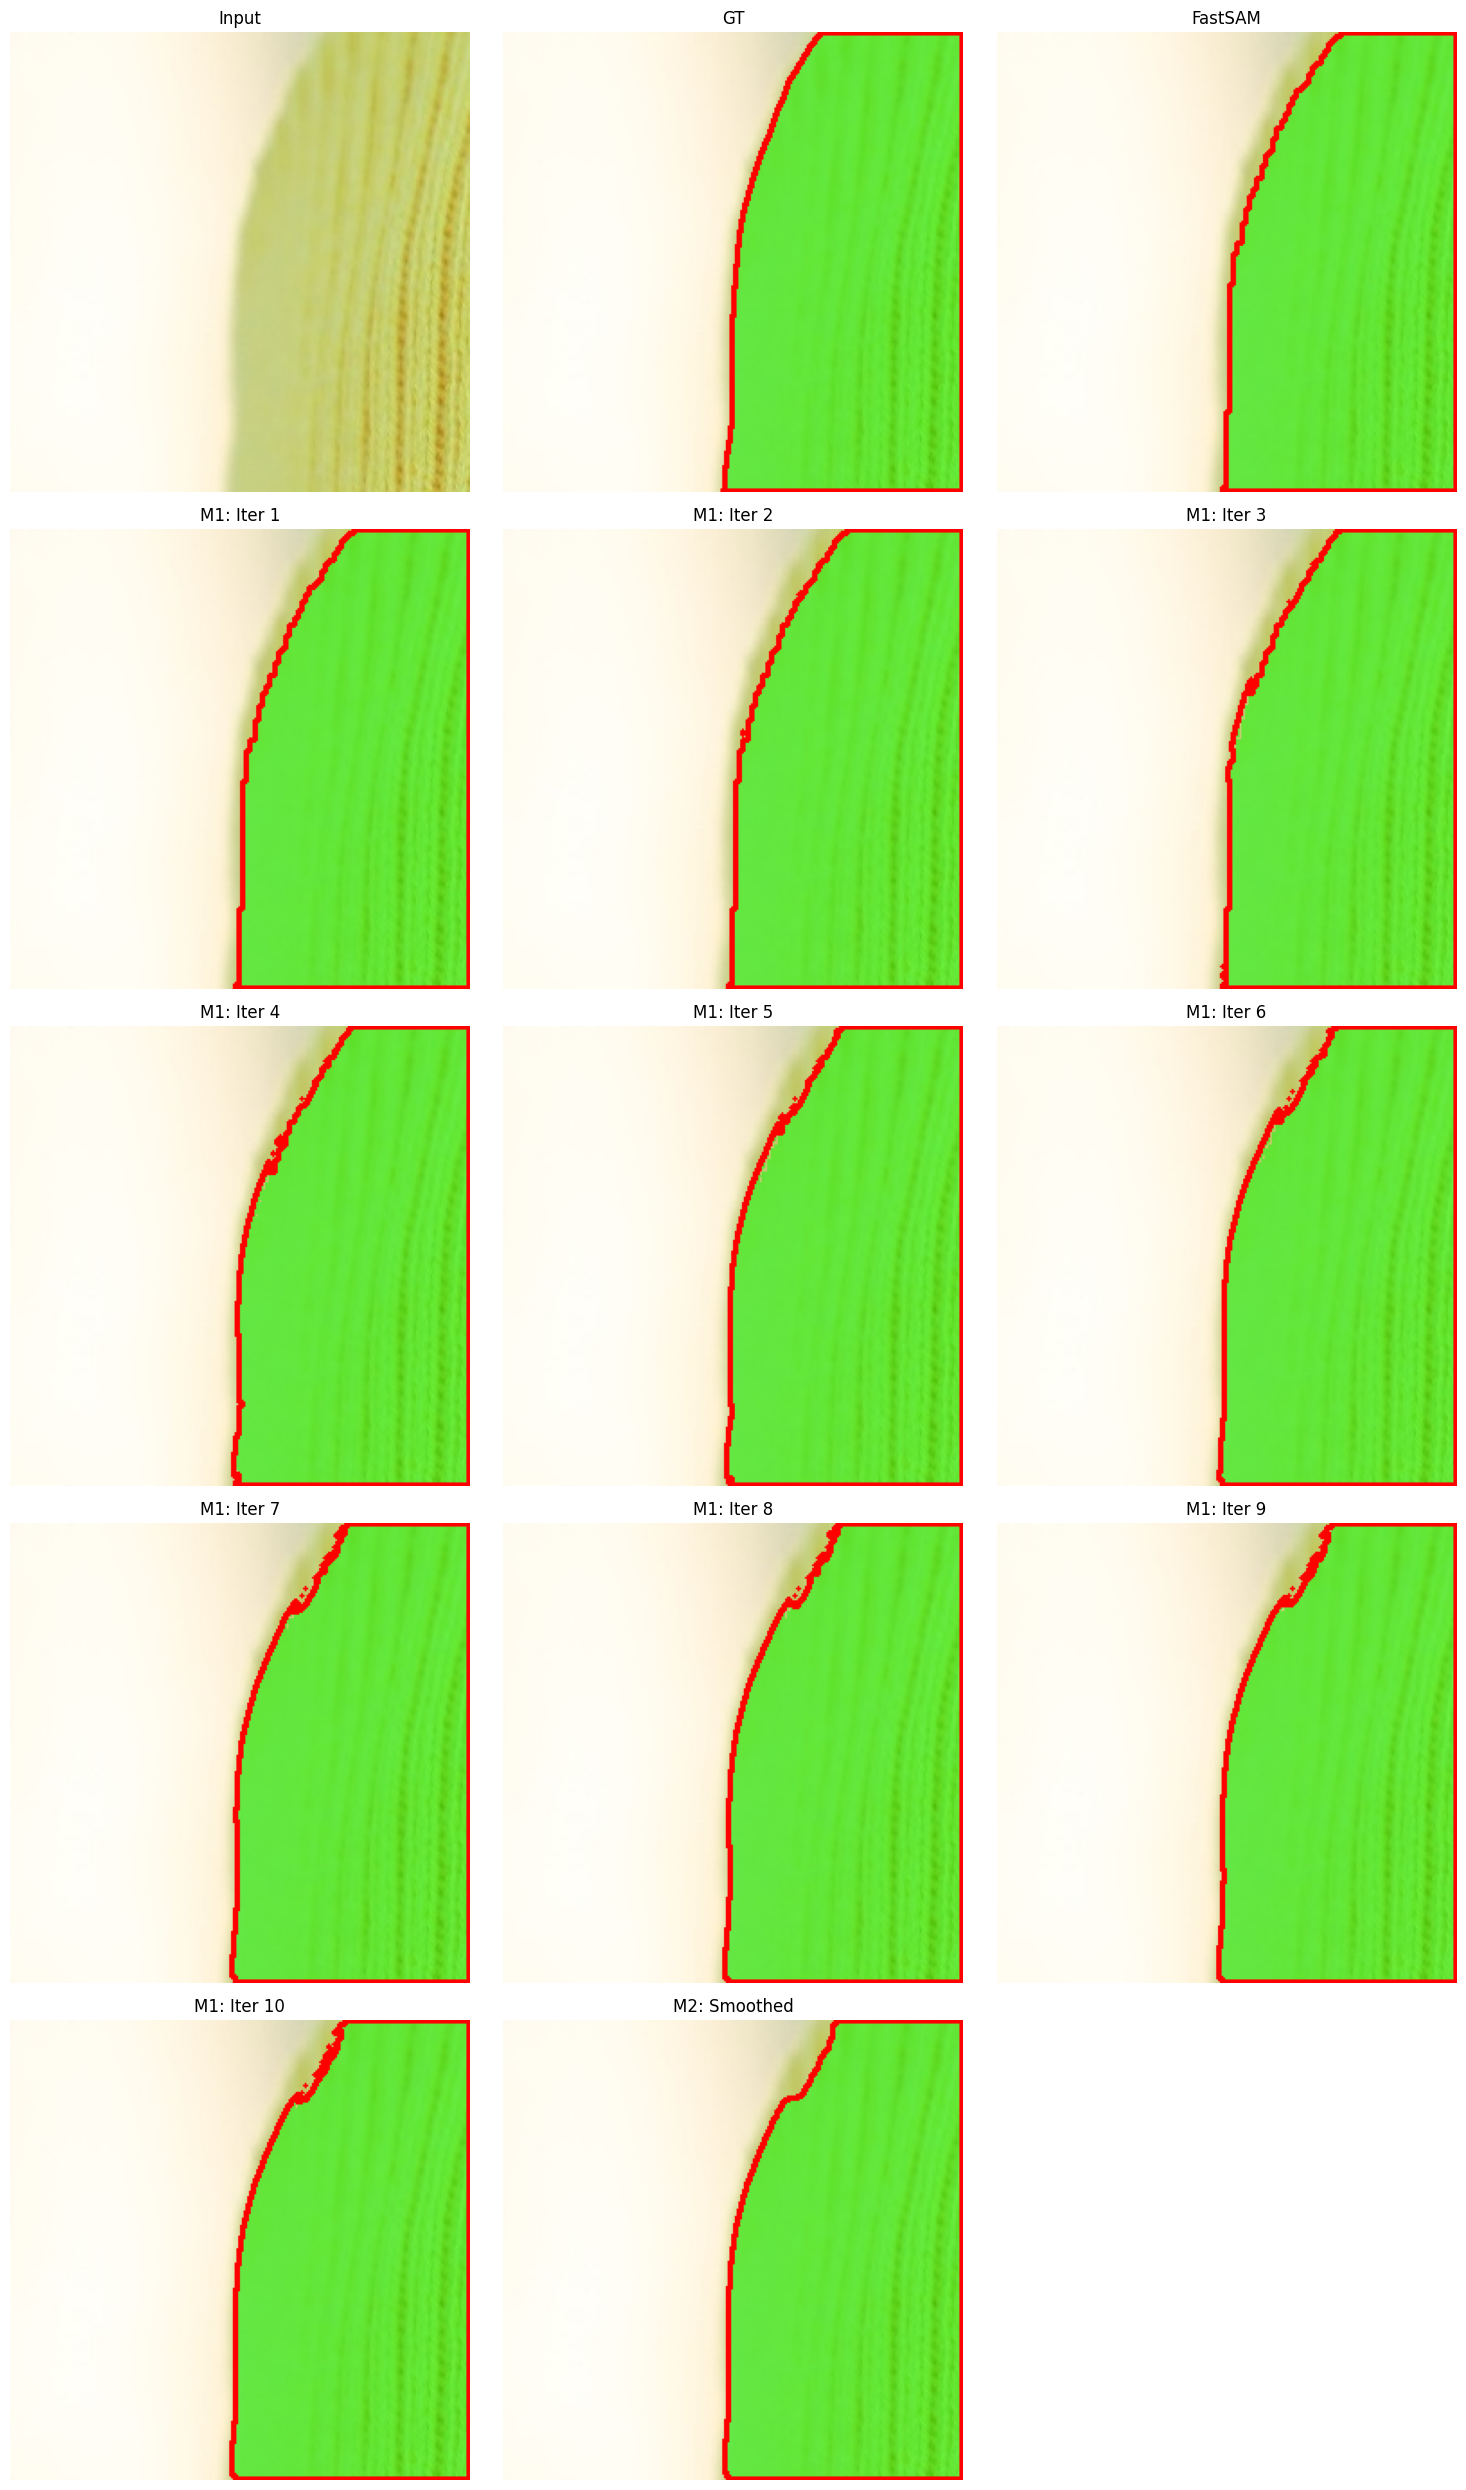

In [31]:
# ===== CLEAR GPU MEMORY =====
import gc
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

gc.collect()
torch.cuda.empty_cache()

# ===================================================
# SET YOUR ITERATIONS HERE
iters_model1 = 10
# ===================================================

# ===== TEST / VISUALIZATION =====

def create_overlay(img_base, mask, mask_color=(0, 255, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    
    alpha = mask_bin[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    return overlay

device = torch.device('cuda:0')

# ===== LOAD MODELS =====
# (Make sure BoundaryPuller and BoundarySmoother are defined/pasted above if needed)
model1 = BoundaryPuller().to(device)
model1.load_state_dict(torch.load("/kaggle/working/puller_final.pth", map_location=device))
model1.eval()

model2 = BoundarySmoother().to(device)
model2.load_state_dict(torch.load("/kaggle/working/smoother_final.pth", map_location=device))
model2.eval()

# ===== PATHS =====
base_path = "/kaggle/input/datasets/deban9017/aip-proj/dat_patch"

test_img_dir = os.path.join(base_path, "val")
test_fs_dir = os.path.join(base_path, "val_masks/fastsam")
test_gt_dir = os.path.join(base_path, "val_masks/gt")

# ===== RANDOM SAMPLE =====
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
img_name = random.choice(test_imgs)
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(os.path.join(test_gt_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)
gt_bin = (gt_mask > 127).astype(np.uint8)

# ===== INFERENCE =====
img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
            .permute(2, 0, 1).unsqueeze(0).to(device)

fs_t = torch.from_numpy(fs_bin.astype(np.float32))\
           .unsqueeze(0).unsqueeze(0).to(device)

m1_step_masks = []

with torch.no_grad():
    # Stage 1: Track the puller step-by-step
    for i in range(1, iters_model1 + 1):
        m1_pred_step = model1(img_t, fs_t, iters=i)
        step_out = m1_pred_step.squeeze().cpu().numpy()
        m1_step_masks.append((step_out > 0.5).astype(np.uint8))
        
        # Save the final iteration's tensor to pass to M2
        if i == iters_model1:
            m1_bin_t = (m1_pred_step > 0.5).float()
    
    # Stage 2: Iron out the jaggies
    m2_pred_t = model2(img_t, m1_bin_t)
    m2_out = m2_pred_t.squeeze().cpu().numpy()

# ===== POST-PROCESS M2 =====
m2_bin_np = (m2_out > 0.5).astype(np.uint8)

# ===== VISUALIZATION =====
total_plots = 4 + iters_model1 # Input, GT, FastSAM, M1 iters, M2
cols = 3
rows = math.ceil(total_plots / cols)

# Dynamically size the figure based on rows
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() # Flatten to 1D array for easy indexing

# Fill the subplots
axes[0].imshow(img_rgb); axes[0].set_title("Input")
axes[1].imshow(create_overlay(img_rgb, gt_bin)); axes[1].set_title("GT")
axes[2].imshow(create_overlay(img_rgb, fs_bin)); axes[2].set_title("FastSAM")

# Dynamic M1 columns
for i in range(iters_model1):
    ax_idx = 3 + i
    axes[ax_idx].imshow(create_overlay(img_rgb, m1_step_masks[i]))
    axes[ax_idx].set_title(f"M1: Iter {i+1}")

# Final M2 column
axes[3 + iters_model1].imshow(create_overlay(img_rgb, m2_bin_np))
axes[3 + iters_model1].set_title("M2: Smoothed")

# Hide axes for all used subplots
for i in range(total_plots):
    axes[i].axis('off')

# Hide any remaining unused subplots completely
for i in range(total_plots, len(axes)):
    axes[i].axis('off')
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


### 🔄 Summary of Updates to the Pipeline

1. **Upgraded Loss Function (Model 2)**
   - Swapped out the basic `SmootherLoss` (BCE + TV) for the new `SmoothBoundaryLoss`. This heavily penalizes scattered/isolated pixels and "holes" using local density checks, forcing a much cleaner boundary.

2. **Training Loop Enhancements (Blocks 5 & 7)**
   - **Learning Rate Scheduler:** Added `ReduceLROnPlateau` to both Stage 1 and Stage 2 training loops to dynamically reduce the LR when the loss stagnates, helping with smoother convergence.
   - **Granular Logging:** Added print statements inside the batch loop (every 20 batches) to track loss progression in real-time instead of waiting for the entire epoch to finish.

3. **Dynamic Step-by-Step Visualization (Block 8)**
   - **Iterative Tracking:** Modified the inference logic to save and visualize the output of *every single iteration* of Model 1 (The Puller) so we can actually see it snapping to the edge step-by-step.
   - **Grid Plotting:** Upgraded the matplotlib logic to dynamically wrap subplots into a grid with a maximum of 3 columns per row. This keeps the images large enough to clearly see the boundary details without cramming them onto one line.

Global Min for plots: -1.4388 | Global Max for plots: 0.9478


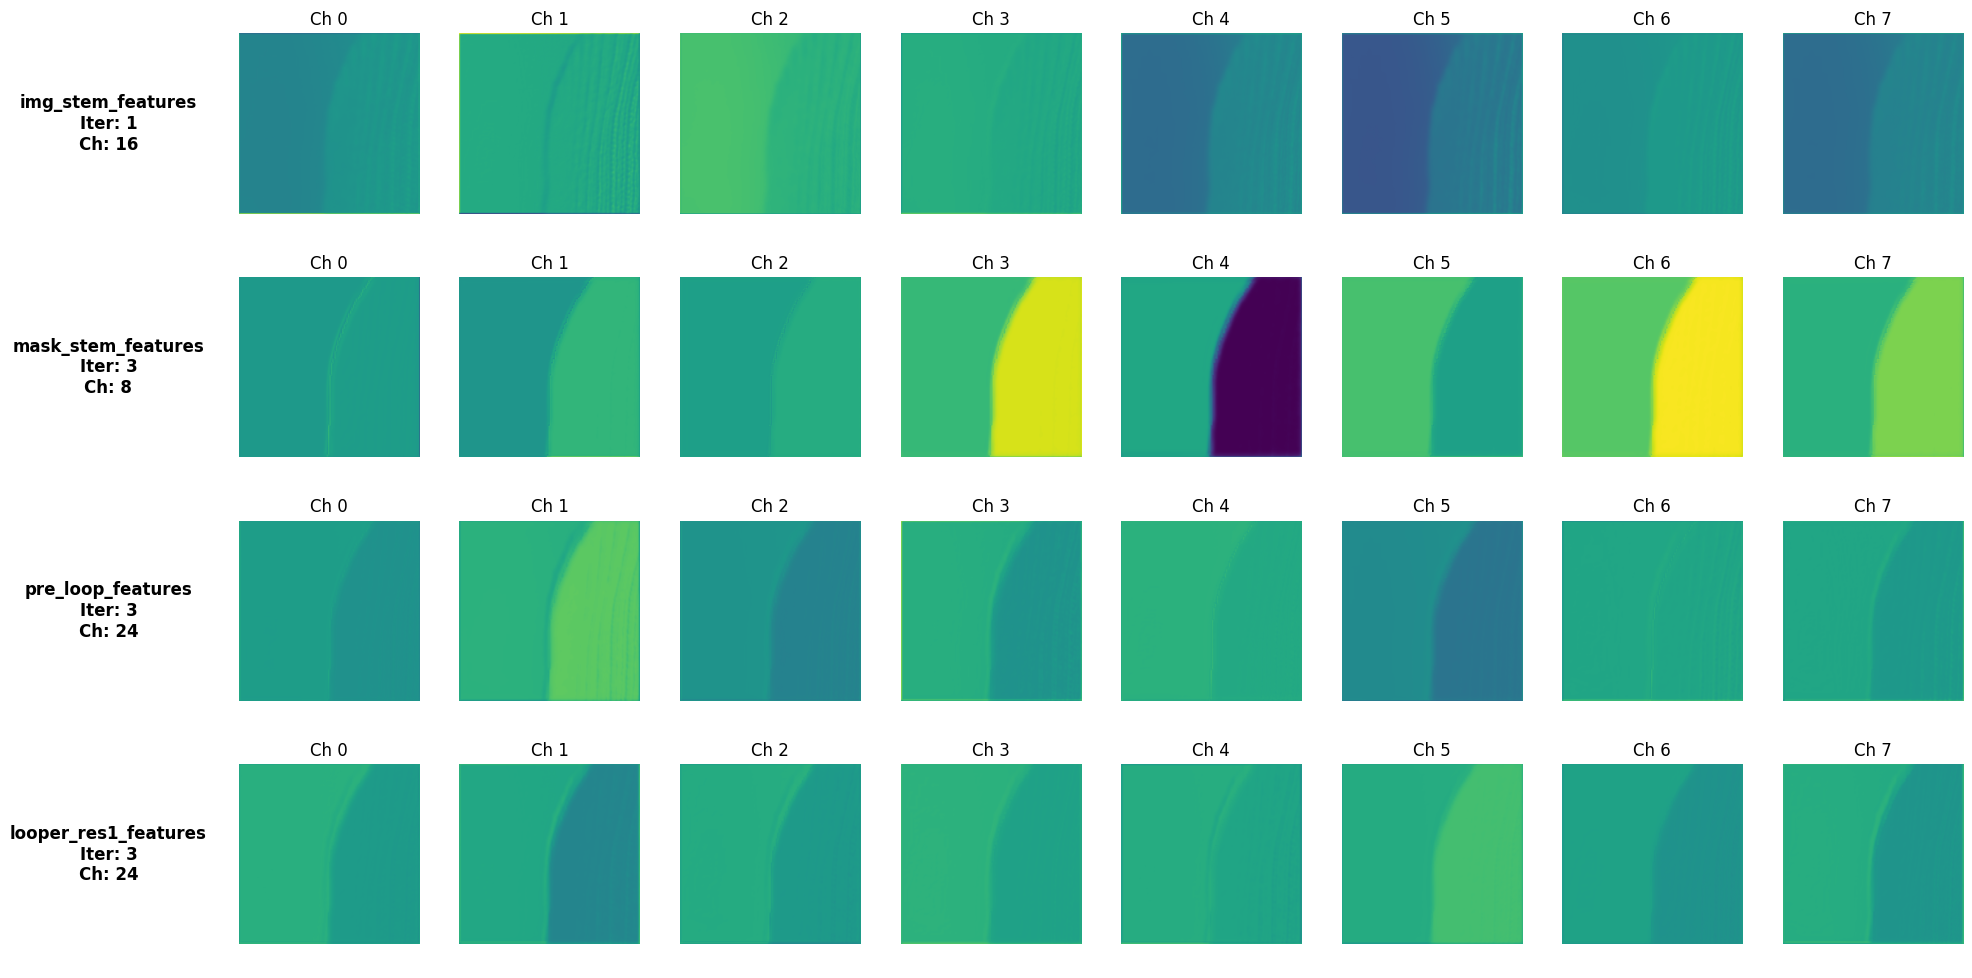

In [32]:
# ===== VISUALIZE ACTIVATION MAPS (GLOBAL SCALING) =====
import torch
import matplotlib.pyplot as plt
import cv2
import os
import random
import numpy as np

# 1. Setup a dictionary to store the features
activations = {}

def get_activation(name):
    def hook(model, input, output):
        if name not in activations:
            activations[name] = []
        # Since our model loops, it will hit some layers multiple times.
        activations[name].append(output.detach().cpu())
    return hook

# 2. Register hooks to key layers in Model 1
hooks = [
    model1.img_stem[2].register_forward_hook(get_activation('img_stem_features')), # Output of 2nd Conv
    model1.mask_stem[0].register_forward_hook(get_activation('mask_stem_features')), 
    model1.pre_loop[0].register_forward_hook(get_activation('pre_loop_features')),
    model1.looper[0].conv1.register_forward_hook(get_activation('looper_res1_features'))
]

# 3. Load a random image and mask
test_imgs = [f for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
# img_name = random.choice(test_imgs) # assuming img_name is defined before
mask_name = img_name.replace('.jpg', '.png')

img = cv2.imread(os.path.join(test_img_dir, img_name))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fs_mask = cv2.imread(os.path.join(test_fs_dir, mask_name), cv2.IMREAD_GRAYSCALE)

fs_bin = (fs_mask > 127).astype(np.uint8)

img_t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
fs_t = torch.from_numpy(fs_bin.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)

# 4. Run Inference
with torch.no_grad():
    _ = model1(img_t, fs_t, iters=3)

# Remove hooks
for h in hooks:
    h.remove()

# 5. Plotting the Activation Maps
iteration_to_view = 2 
max_channels_to_show = 8 

layers_to_plot = ['img_stem_features', 'mask_stem_features', 'pre_loop_features', 'looper_res1_features']

# --- NEW: Loop once to find absolute min and max ---
global_min = float('inf')
global_max = float('-inf')

for layer_name in layers_to_plot:
    iter_idx = 0 if layer_name == 'img_stem_features' else iteration_to_view
    layer_tensor = activations[layer_name][iter_idx].squeeze(0)
    
    # Just check the channels we are actually plotting
    channels_to_check = layer_tensor[:max_channels_to_show]
    
    global_min = min(global_min, channels_to_check.min().item())
    global_max = max(global_max, channels_to_check.max().item())

print(f"Global Min for plots: {global_min:.4f} | Global Max for plots: {global_max:.4f}")

fig, axes = plt.subplots(len(layers_to_plot), max_channels_to_show + 1, figsize=(20, 2.5 * len(layers_to_plot)))

for row, layer_name in enumerate(layers_to_plot):
    iter_idx = 0 if layer_name == 'img_stem_features' else iteration_to_view
    layer_tensor = activations[layer_name][iter_idx].squeeze(0)
    num_channels = layer_tensor.shape[0]
    
    # Text info column
    axes[row, 0].axis('off')
    axes[row, 0].text(0.5, 0.5, f"{layer_name}\nIter: {iter_idx+1}\nCh: {num_channels}", 
                      ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Plot filters
    for col in range(max_channels_to_show):
        ax = axes[row, col + 1]
        if col < num_channels:
            feature_map = layer_tensor[col].numpy()
            
            # --- NEW: Pass global limits to vmin and vmax ---
            ax.imshow(feature_map, cmap='viridis', vmin=global_min, vmax=global_max)
            ax.set_title(f"Ch {col}")
        
        ax.axis('off')

plt.tight_layout()
plt.show()

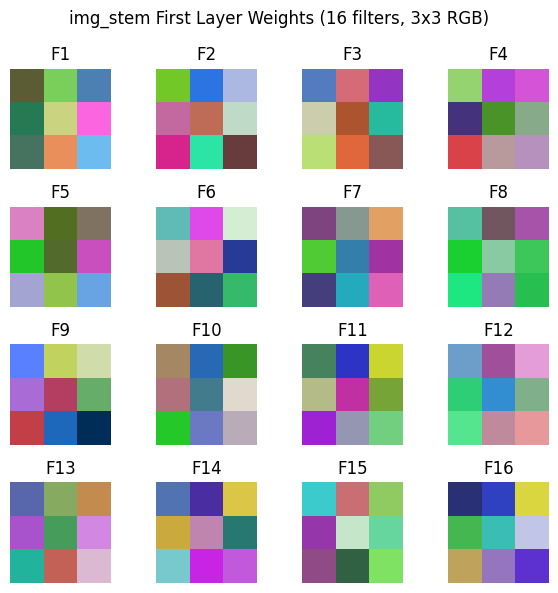

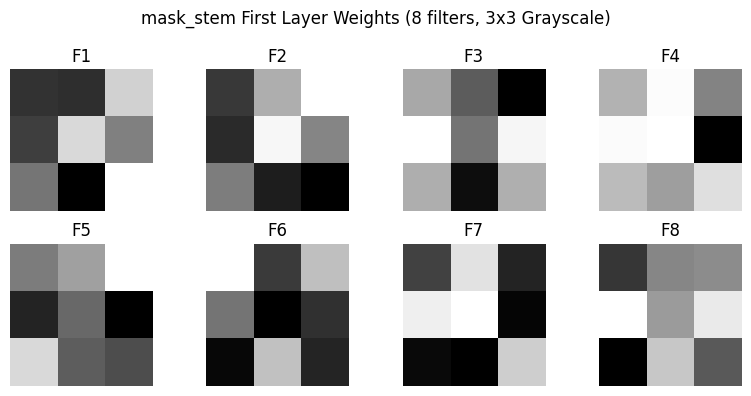

In [33]:
# ===== VISUALIZE MODEL WEIGHTS (FILTERS) =====
import torch
import matplotlib.pyplot as plt

# 1. Visualize img_stem first layer (Conv2d(3, 16, 3))
# Shape of weights: [16, 3, 3, 3] -> [out_channels, in_channels, H, W]
img_filters = model1.img_stem[0].weight.data.cpu().numpy()

# Normalize filters to 0-1 range so matplotlib doesn't throw errors
f_min, f_max = img_filters.min(), img_filters.max()
img_filters = (img_filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle("img_stem First Layer Weights (16 filters, 3x3 RGB)", fontsize=12)

for i, ax in enumerate(axes.flatten()):
    # Transpose from (C, H, W) to (H, W, C) for plotting RGB
    filter_rgb = img_filters[i].transpose(1, 2, 0)
    
    # Resize it slightly just for display purposes so it's not super blurry
    import cv2
    filter_resized = cv2.resize(filter_rgb, (30, 30), interpolation=cv2.INTER_NEAREST)
    
    ax.imshow(filter_resized)
    ax.axis('off')
    ax.set_title(f"F{i+1}")

plt.tight_layout()
plt.show()

# 2. Visualize mask_stem first layer (Conv2d(1, 8, 3))
# Shape of weights: [8, 1, 3, 3]
mask_filters = model1.mask_stem[0].weight.data.cpu().numpy()

m_min, m_max = mask_filters.min(), mask_filters.max()
mask_filters = (mask_filters - m_min) / (m_max - m_min)

fig2, axes2 = plt.subplots(2, 4, figsize=(8, 4))
fig2.suptitle("mask_stem First Layer Weights (8 filters, 3x3 Grayscale)", fontsize=12)

for i, ax in enumerate(axes2.flatten()):
    # Squeeze the channel dimension out since it's just 1
    filter_gray = mask_filters[i].squeeze(0)
    
    import cv2
    filter_gray_resized = cv2.resize(filter_gray, (30, 30), interpolation=cv2.INTER_NEAREST)
    
    ax.imshow(filter_gray_resized, cmap='gray')
    ax.axis('off')
    ax.set_title(f"F{i+1}")

plt.tight_layout()
plt.show()